# AG-HYPOPT · Trial 15

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Fourteen trials are registered; cell 2 reports `phase = trials` (14/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). The relevant picture (mu travel = `lr_mu*(1 - mu_anneal/2)`), focussing on the many divergence-free runs around the optimum:

- **trial_08 (0.1099, best, 0 div):** travel 0.134, `lr_gamma=0.416`, `gamma_anneal=0.532`.
- optimum cluster (0 div): trial_12 0.1115 (0.128), trial_09 0.1126 (0.123), trial_01 0.1127 (0.120), trial_14 0.1127 (0.140), trial_13 0.1132 (0.134).
- slightly below: trial_05 0.1135 (0.088), trial_07 0.1140 (0.097).
- worse: trial_11 0.1188 (0.159, overshoot), trial_06 0.1188 (0.082).
- diverging: trial_10 0.1975 (0.099, 3nW T60), trial_03 0.1362 (0.074), trial_04 0.1418 (0.074), trial_02 0.1449 (0.264).

State of play: nine divergence-free runs now bracket a flat optimum at mu travel ~0.13, with objectives 0.1099-0.1140 and no clean dependence on the gamma schedule (trials 08/09/12/13/14). The persistent, un-tuned residuals are the mid-T mu overshoot (~+146% to +160% in the best runs) and the 3nW high-T mu undershoot (~-22% to -36%), plus low-T gamma under-recovery. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_15'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (14/5 trials)
ID |     ei | params
 1 | 3.9512 | {"gamma_anneal": 0.5062423011096853, "lr_gamma": 0.45037580491905266, "lr_mu": 0.15427602870079982, "mu_anneal": 0.3545851963503213}
 2 | 1.6220 | {"gamma_anneal": 0.5663187692707677, "lr_gamma": 0.5113631093843939, "lr_mu": 0.15406719097679122, "mu_anneal": 0.8891839058918612}
 3 | 3.5914 | {"gamma_anneal": 0.49800221804269723, "lr_gamma": 0.4426408340996401, "lr_mu": 0.10324033416688438, "mu_anneal": 0.3375714947975939}
 4 | 3.7802 | {"gamma_anneal": 0.5031066158058775, "lr_gamma": 0.45536589440204134, "lr_mu": 0.09487546183248113, "mu_anneal": 0.320011796895653}
 5 | 2.7711 | {"gamma_anneal": 0.22218281348021232, "lr_gamma": 0.453678526734129, "lr_mu": 0.1115531061304601, "mu_anneal": 0.3428689983340756}
 6 | 3.2662 | {"gamma_anneal": 0.5575061686146218, "lr_gamma": 0.4698443248769529, "lr_mu": 0.13238152349648666, "mu_anneal": 0.772998502208093}
 7 | 3.8600 | {"gamma_anneal": 0.5938806538724466, "lr_gamma": 0.49361481

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (14 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 1: **ei 3.95** — `lr_mu=0.154`, `mu_anneal=0.355` (travel **0.127**), `lr_gamma=0.450`, `gamma_anneal=0.506`.
- candidate 8: ei 3.89 — `lr_mu=0.129`, `mu_anneal=0.344` (travel 0.107), `lr_gamma=0.480`, `gamma_anneal=0.566`.
- candidate 7: ei 3.86 — `lr_mu=0.147`, `mu_anneal=0.353` (travel 0.121), `lr_gamma=0.494`, `gamma_anneal=0.594`.
- candidate 4: ei 3.78 — `lr_mu=0.095`, `mu_anneal=0.320` (travel 0.080), `lr_gamma=0.455`.
- candidate 3: ei 3.59 — `lr_mu=0.103`, `mu_anneal=0.338` (travel 0.086), `lr_gamma=0.443`.

Candidate 1 has the highest ei and lands squarely on the optimum (travel 0.127, between trial_12's 0.128 and trial_01's 0.120; mu knobs between trial_08's and trial_12's). The top four candidates all cluster at travel 0.080-0.127 with `lr_gamma` ~0.44-0.49, i.e. the algorithm is now densely resampling the good region; candidate 1 is simply its best-centred point there. Given the region is flat and the top-ei candidates are near-duplicates, following the maximum-ei candidate is the natural choice — it is a low-risk sample of the optimum with a gamma schedule in the proven-safe range. The lower-travel candidates (3, 4 at 0.080-0.086) are nearer the region where trials 06/10 lost or diverged; candidates 7/8 are similar to candidate 1 but lower ei.

I choose candidate 1 (1 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5062423011096853, 'lr_gamma': 0.45037580491905266, 'lr_mu': 0.15427602870079982, 'mu_anneal': 0.3545851963503213}
Running  1nW Trans05 ... 

μ 9.39 -> 10.17 | γ 8.5 -> 4.46 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 43.56 | γ 8.5 -> 6.22 | NLL 5.03


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 77.20 | γ 14.1 -> 14.31 | NLL 3.31


Running 3nW Trans100 ... 

μ 175.71 -> 110.78 | γ 14.1 -> 14.12 | NLL 2.99



Total: 8.0 min


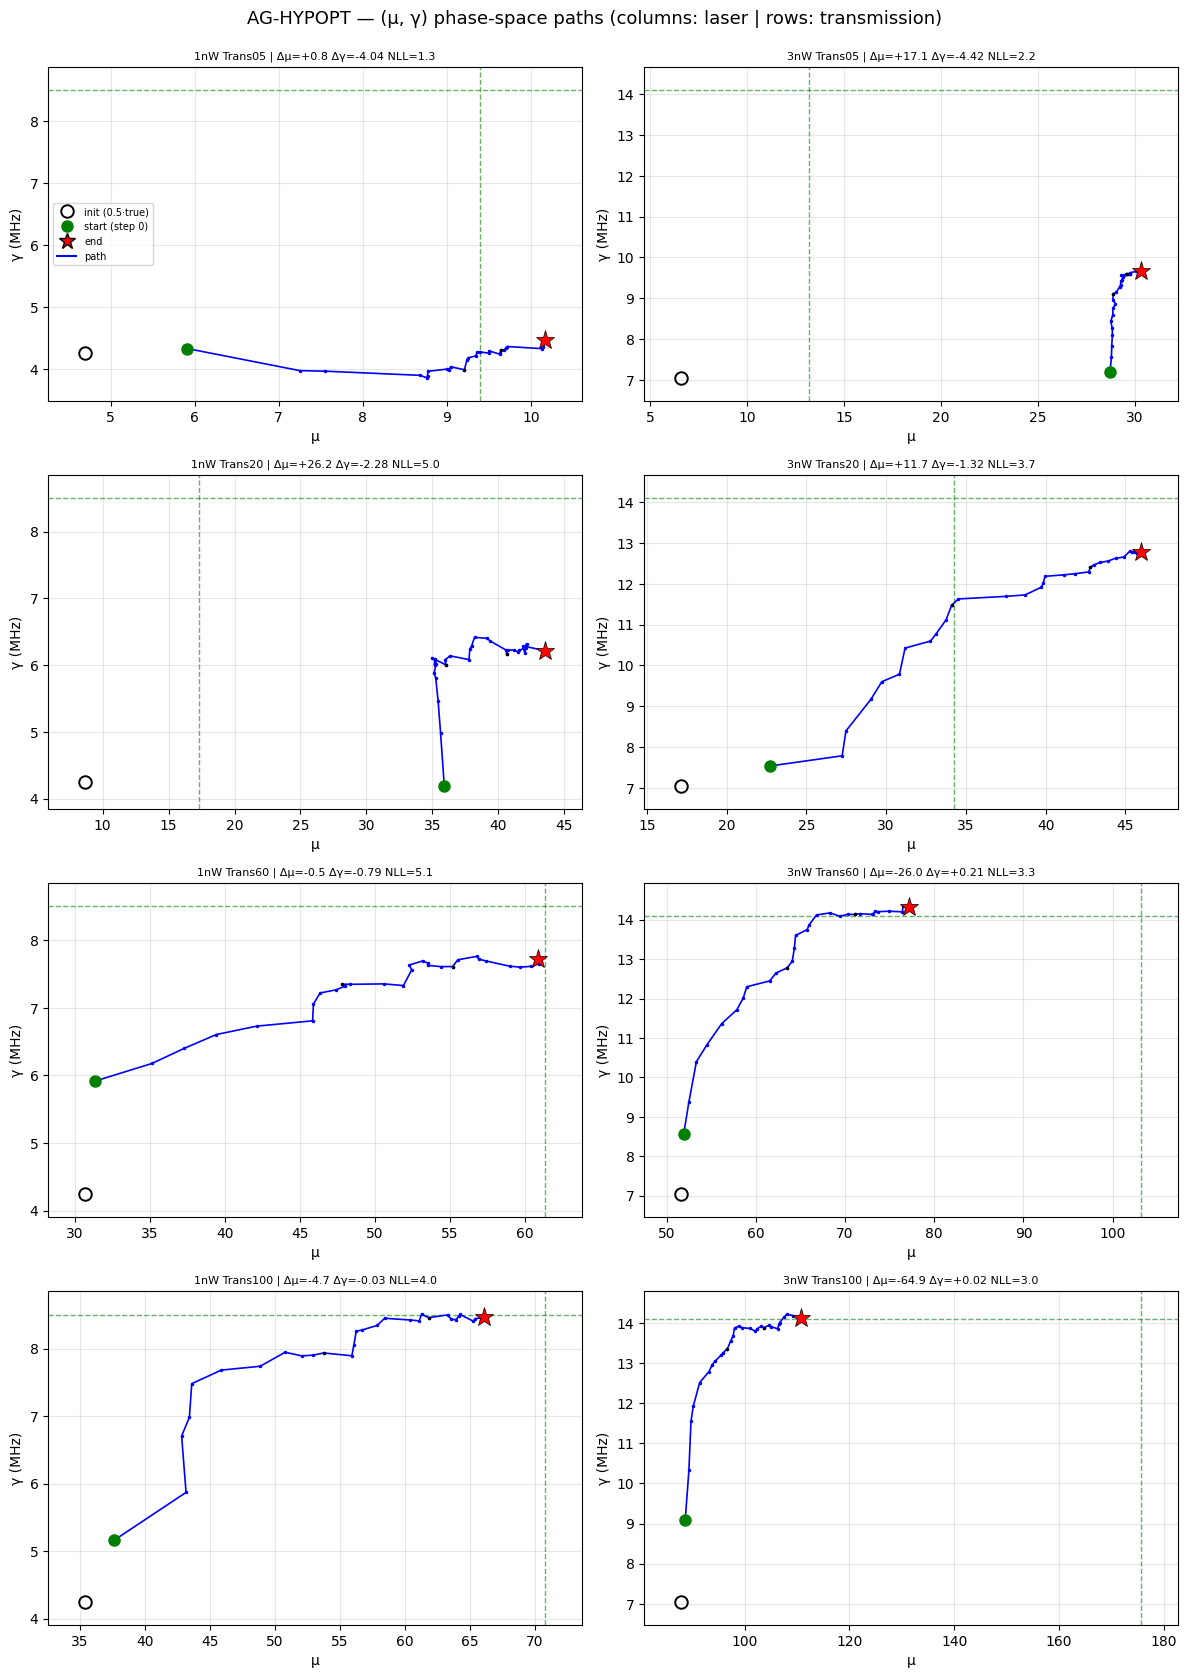

trial finished in 8.0 min
objective = 0.1103 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.17    +8.3 |     8.50    4.46   -47.5
1nW Trans20       17.32   43.56  +151.6 |     8.50    6.22   -26.9
1nW Trans60       61.37   60.89    -0.8 |     8.50    7.71    -9.2
1nW Trans100       70.82   66.14    -6.6 |     8.50    8.47    -0.3
3nW Trans05       13.20   30.33  +129.7 |    14.10    9.68   -31.4
3nW Trans20       34.28   45.99   +34.2 |    14.10   12.78    -9.3
3nW Trans60      103.20   77.20   -25.2 |    14.10   14.31    +1.5
3nW Trans100      175.71  110.78   -37.0 |    14.10   14.12    +0.2

weighted objective (T-graded, cap=1.0) = 0.1103 | diverged cells: 0
μ: RMSE 27.464 (rel 73.4%, bias -5.029) | γ: RMSE 2.332 (rel 22.8%, bias -1.580)


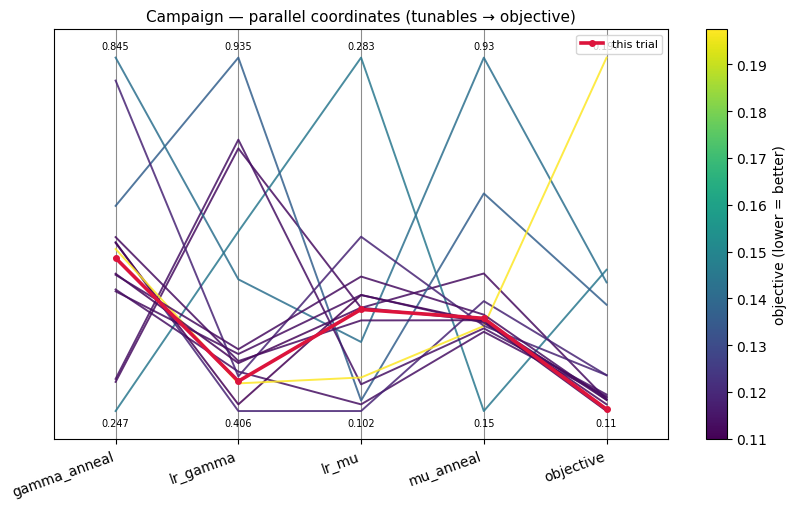

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 15 ran the highest-EI candidate (candidate 1, ei=3.95): `lr_mu=0.1543`, `mu_anneal=0.3546` (effective mu travel 0.127), `lr_gamma=0.4504`, `gamma_anneal=0.5062`. It completed in 8.0 min with objective **0.1103 +/- 0.0825** and **0 diverged cells** — the closest yet to trial_08 (0.1099). Ranking: trial_08 0.1099 < **trial_15 0.1103** < trial_12 0.1115 < trial_09 0.1126 < trial_01 = trial_14 0.1127 < trial_13 0.1132 < ...

Aggregate accuracy: **mu rel-RMSE 73.4%** (RMSE 27.46, bias -5.03); **gamma rel-RMSE 22.8%** (RMSE 2.33, bias -1.58).

Per-cell relative errors:
- **mu:** 1nW T05 +8.3%, T20 +151.6%, T60 -0.8%, T100 -6.6% | 3nW T05 +129.7%, T20 +34.2%, T60 -25.2%, T100 -37.0%.
- **gamma:** 1nW T05 -47.5%, T20 -26.9%, T60 -9.2%, T100 -0.3% | 3nW T05 -31.4%, T20 -9.3%, T60 +1.5%, T100 +0.2%.

Another optimum-region sample (travel 0.127, mu knobs between trial_08's and trial_12's) and by far the closest to the best: 0.1103 vs 0.1099. Its 1nW high-T cells were strong (T60 -0.8%, T100 -6.6%) and gamma was clean at high T, but the same residuals remain (1nW T20 +151.6%, 3nW T05 +129.7%, 3nW T100 -37.0%). Ten divergence-free runs now span the optimum (trials 01, 05, 06, 07, 08, 09, 12, 13, 14, 15) with objectives 0.1099-0.1188, and the six best of them differ by under 0.004. The campaign has effectively converged with this schedule family; trial_08 remains the best single point.

**Summary:** Trial 15 (lr_mu=0.1543, mu_anneal=0.3546, lr_gamma=0.4504, gamma_anneal=0.5062): objective 0.1103 +/- 0.0825 with 0 diverged cells; another optimum-region sample (travel 0.127) came within 0.0004 of trial_08 (0.1099), which remains the best.
**Key insight:** The optimum region (travel 0.12-0.14) keeps producing 0.1099-0.1132; trial_15's 0.1103 is the closest yet to trial_08 but still does not beat it, reinforcing that the best achievable value with this schedule family is ~0.110 and further tuning yields no real gain.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** With ~10 optimum samples all in 0.110-0.118 and the same residual structure, the hyperparameter search has plateaued. The remaining error is dominated by mid-T mu overshoot and 3nW high-T mu undershoot, neither of which the four knobs address — a structural rather than hyperparameter problem. The campaign can still register a few more samples, but no further gains should be expected from this search space; recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 15 (lr_mu=0.1543, mu_anneal=0.3546, lr_gamma=0.4504, gamma_anneal=0.5062): objective 0.1103 +/- 0.0825 with 0 diverged cells; another optimum-region sample (travel 0.127) came within 0.0004 of trial_08 (0.1099), which remains the best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The optimum region (travel 0.12-0.14) keeps producing 0.1099-0.1132; trial_15's 0.1103 is the closest yet to trial_08 but still does not beat it, reinforcing that the best achievable value with this schedule family is ~0.110 and further tuning yields no real gain"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_15 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_16.ipynb. Open it and follow its cells from the top.
